In [13]:
# Cell 1: Imports and Setup
import numpy as np
import matplotlib.pyplot as plt

# Ensures plots are rendered inline in Jupyter
%matplotlib inline

# Set seed for reproducibility
np.random.seed(42)

# --- (a) Generate 100 random synthetic samples ---
# Input shape: (m, Dx) = (100, 200)
m = 100
Dx = 200
X = np.random.randn(m, Dx)

# --- (b) Generate 100 random class labels and convert to one-hot ---
# Labels 0 to 9, C = 10
C = 10
labels = np.random.randint(0, C, size=m)

# One-hot encoding for Y matrix (shape: 100 x 10)
Y = np.zeros((m, C))
Y[np.arange(m), labels] = 1

print(f"Data generated: X shape {X.shape}, Y shape {Y.shape}")


Data generated: X shape (100, 200), Y shape (100, 10)


In [14]:
# Cell 2: Neural Network Implementation (From Scratch)
def tanh(z):
    return np.tanh(z)

def softmax(z):
    # Numerical stability: subtract max
    shift_z = z - np.max(z, axis=0, keepdims=True)
    exp_z = np.exp(shift_z)
    return exp_z / np.sum(exp_z, axis=0, keepdims=True)

# --- (c) & (d) Model Initialization and Forward Pass ---
Da1 = 20  # Hidden layer neurons

# Initialize Weights and Biases
# Using standard normal distribution scaled for stability
W1 = np.random.randn(Da1, Dx) * 0.01
b1 = np.zeros((Da1, 1))
W2 = np.random.randn(C, Da1) * 0.01
b2 = np.zeros((C, 1))

# Forward Pass Logic
# Note: Input X is (m, Dx). We use X.T to get (Dx, m) to match x^(i) notation
X_input = X.T 

# Layer 1: $z_1 = W_1 x^{(i)} + b_1$, $a_1 = \tanh(z_1)$
z1 = np.dot(W1, X_input) + b1
a1 = tanh(z1)

# Layer 2: $z_2 = W_2 a_1 + b_2$, $\hat{y} = \text{softmax}(z_2)$
z2 = np.dot(W2, a1) + b2
y_hat = softmax(z2)

# --- (e) Compute average cross-entropy loss ---
# $L^{(i)} = -\sum y_j^{(i)} \log(\hat{y}_j^{(i)})$
epsilon = 1e-12 # avoid log(0)
loss_per_sample = -np.sum(Y.T * np.log(y_hat + epsilon), axis=0)
average_loss = np.mean(loss_per_sample)

print(f"Forward pass completed. Average Cross-Entropy Loss: {average_loss:.4f}")

Forward pass completed. Average Cross-Entropy Loss: 2.3020


In [15]:
# Cell 3: Metrics Calculation
predictions = np.argmax(y_hat, axis=0)
true_classes = labels

def get_metrics(y_true, y_pred, n_classes):
    accuracy = np.mean(y_true == y_pred)
    
    precisions, recalls, f1s = [], [], []
    for c in range(n_classes):
        tp = np.sum((y_pred == c) & (y_true == c))
        fp = np.sum((y_pred == c) & (y_true != c))
        fn = np.sum((y_pred != c) & (y_true == c))
        
        p = tp / (tp + fp) if (tp + fp) > 0 else 0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0
        f = 2 * p * r / (p + r) if (p + r) > 0 else 0
        
        precisions.append(p)
        recalls.append(r)
        f1s.append(f)
        
    return accuracy, np.mean(precisions), np.mean(recalls), np.mean(f1s)

acc, prec, rec, f1 = get_metrics(true_classes, predictions, C)

print(f"Performance Metrics:\n{'='*20}")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")

Performance Metrics:
Accuracy:  0.1700
Precision: 0.1934
Recall:    0.1669
F1-Score:  0.1669


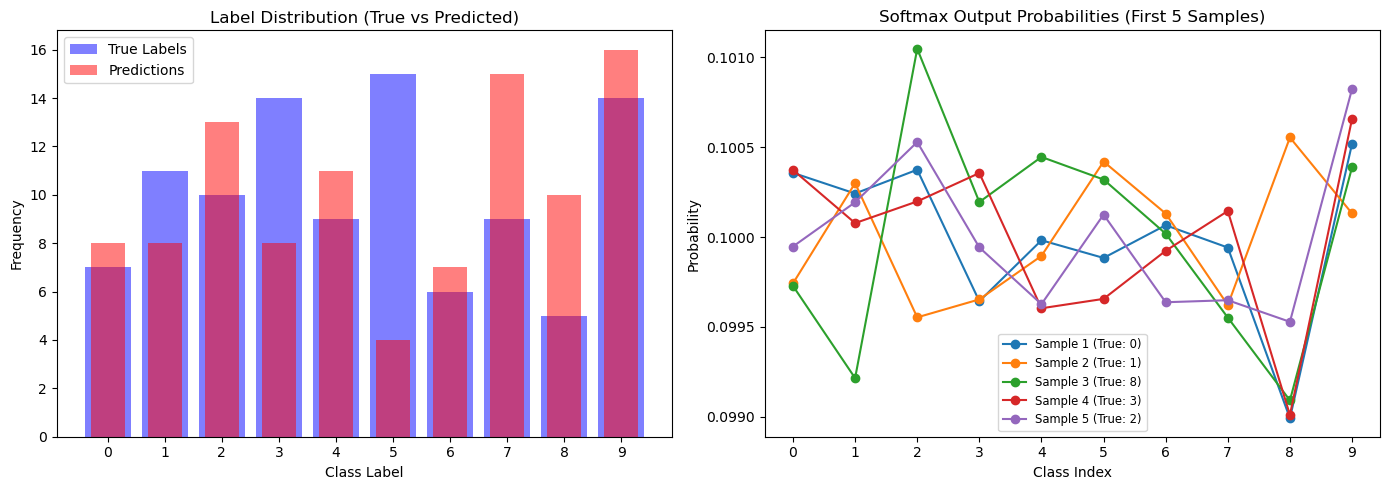

In [16]:
# Cell 4: Visualization
plt.figure(figsize=(14, 5))

# Plot 1: Actual vs Predicted Distribution
plt.subplot(1, 2, 1)
bins = np.arange(C + 1) - 0.5
plt.hist(true_classes, bins=bins, alpha=0.5, label='True Labels', color='blue', rwidth=0.8)
plt.hist(predictions, bins=bins, alpha=0.5, label='Predictions', color='red', rwidth=0.6)
plt.title('Label Distribution (True vs Predicted)')
plt.xlabel('Class Label')
plt.ylabel('Frequency')
plt.xticks(range(C))
plt.legend()

# Plot 2: Softmax Probabilities for the first 5 samples
plt.subplot(1, 2, 2)
for i in range(5):
    plt.plot(range(C), y_hat[:, i], marker='o', label=f'Sample {i+1} (True: {true_classes[i]})')
plt.title('Softmax Output Probabilities (First 5 Samples)')
plt.xlabel('Class Index')
plt.ylabel('Probability')
plt.xticks(range(C))
plt.legend(fontsize='small')

plt.tight_layout()
plt.show()